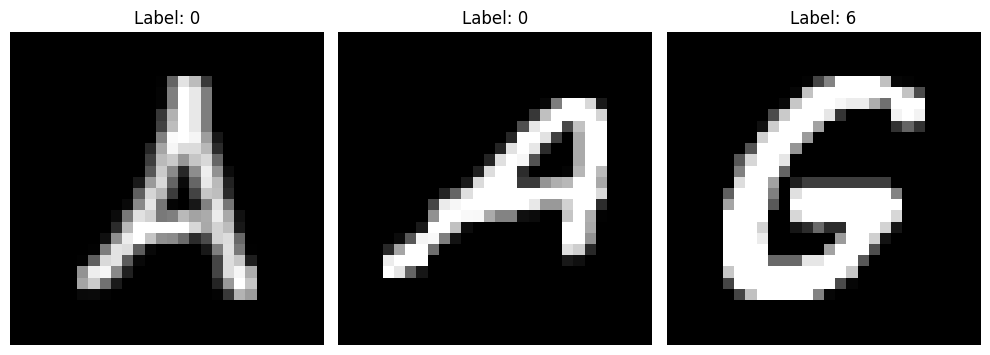

In [2]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
df = pd.read_csv(r"D:\BackUp_Dec_2025\Predictive_project\A_Z Handwritten Data.csv")
labels = df.iloc[:, 0]
pixels = df.iloc[:, 1:]
indices = [10, 5000, 70789]

plt.figure(figsize=(10, 4))

for j, i in enumerate(indices):
    img = pixels.iloc[i].values.reshape(28, 28)
    
    plt.subplot(1, 3, j+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels.iloc[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [3]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy (No FE):", acc_rf)

Random Forest Accuracy (No FE): 0.9840247013021882


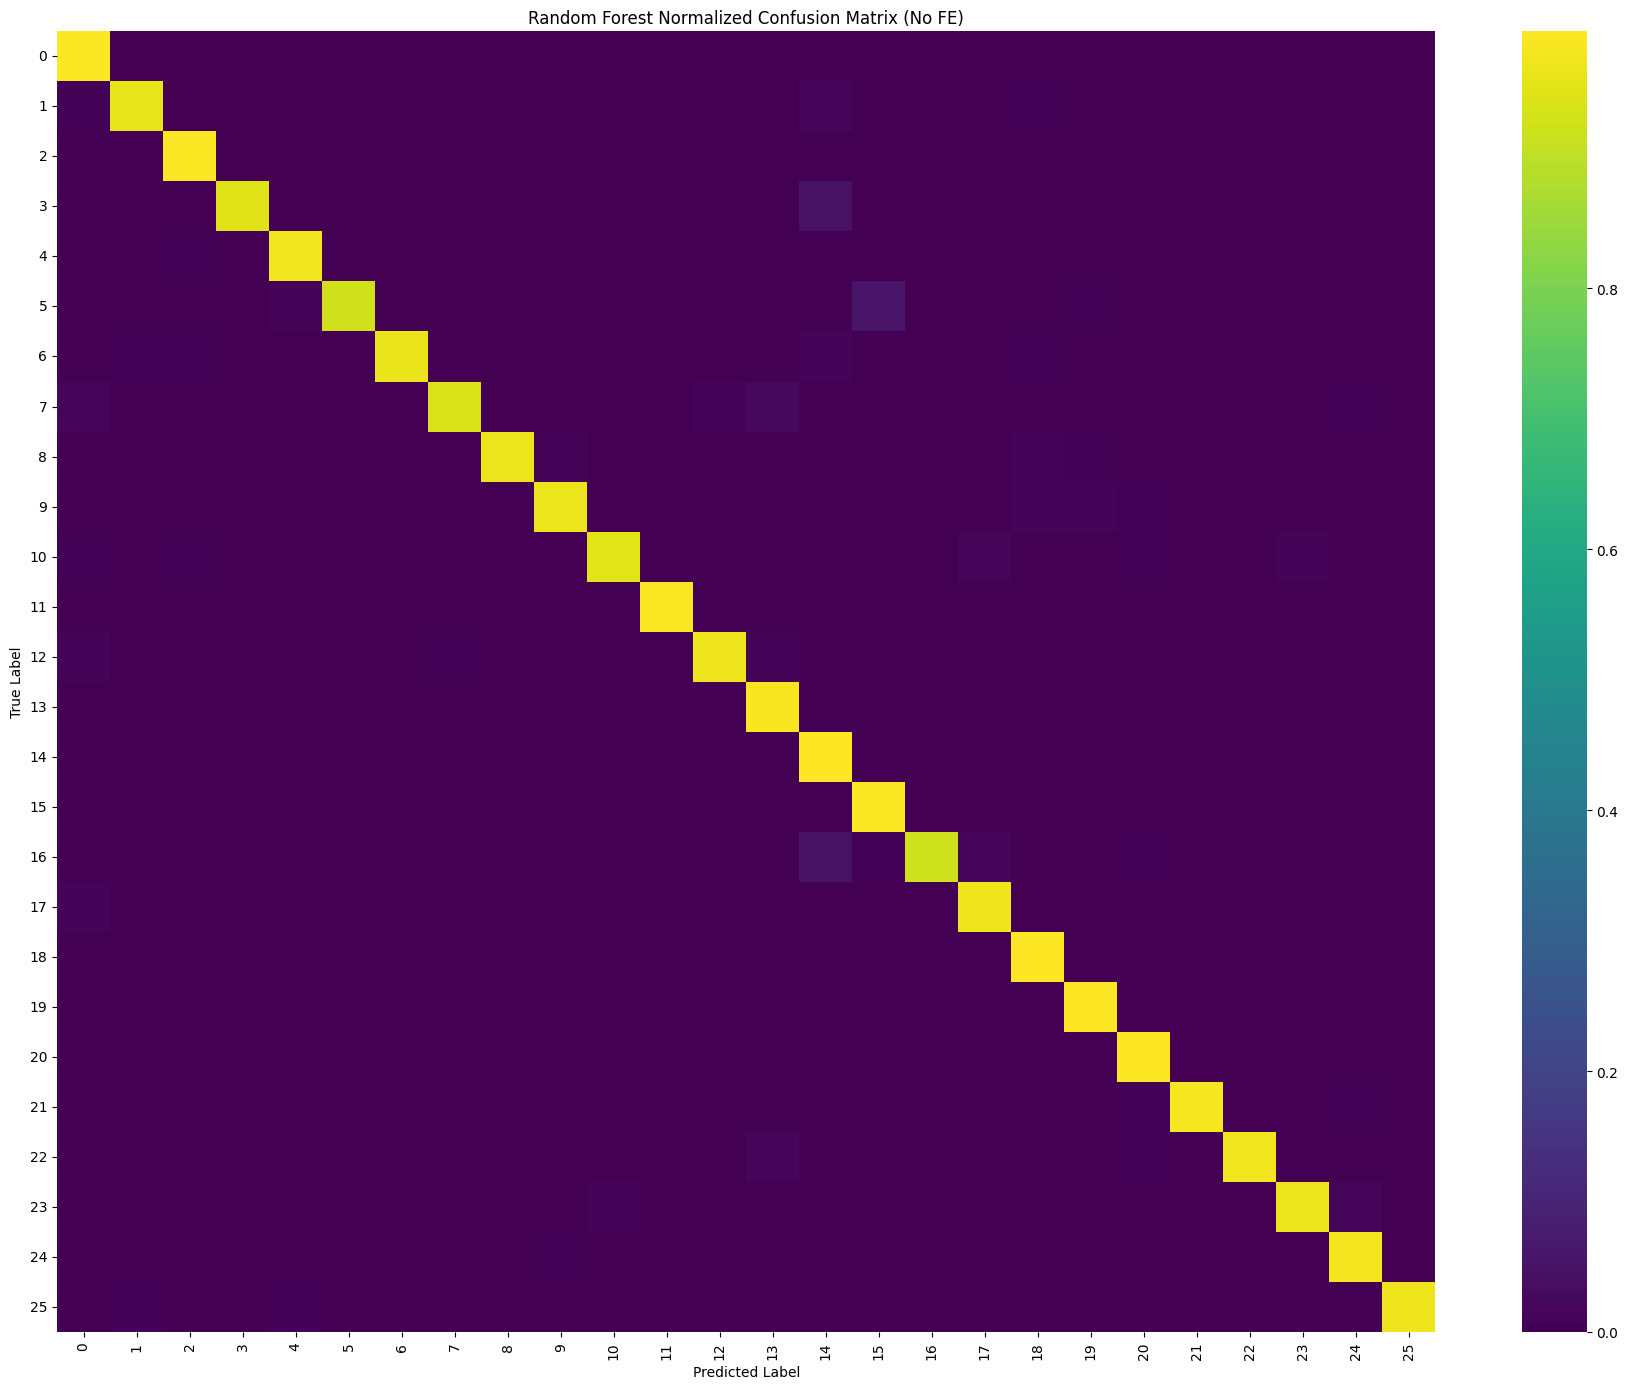

In [6]:
cm_rf_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18,14))
sns.heatmap(cm_rf_norm, annot=False, cmap="viridis")
plt.title("Random Forest Normalized Confusion Matrix (No FE)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


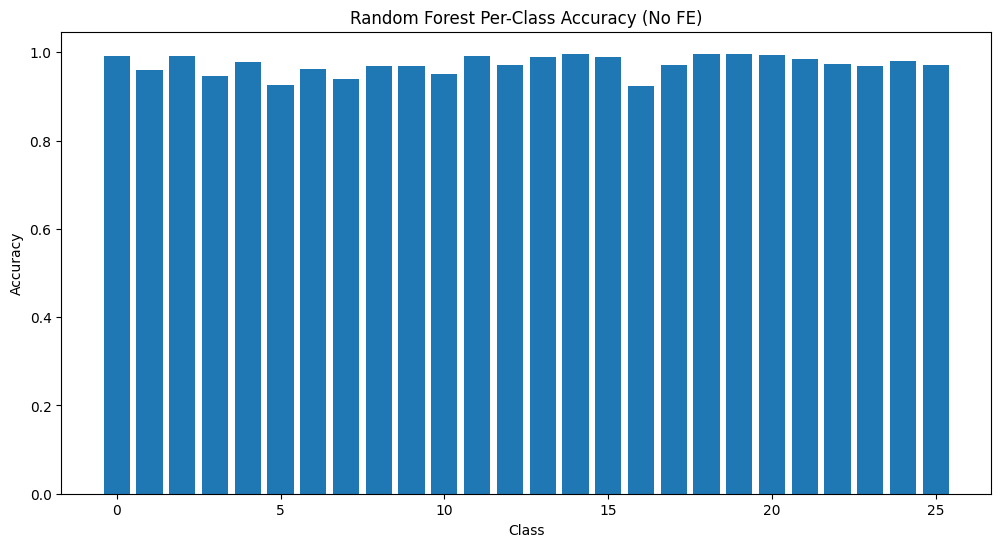

In [7]:
classes = sorted(y_test.unique())
acc_rf_classes = []

for c in classes:
    idx = (y_test == c)
    acc_rf_classes.append((y_pred_rf[idx] == c).mean())

plt.figure(figsize=(12,6))
plt.bar(classes, acc_rf_classes)
plt.title("Random Forest Per-Class Accuracy (No FE)")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()


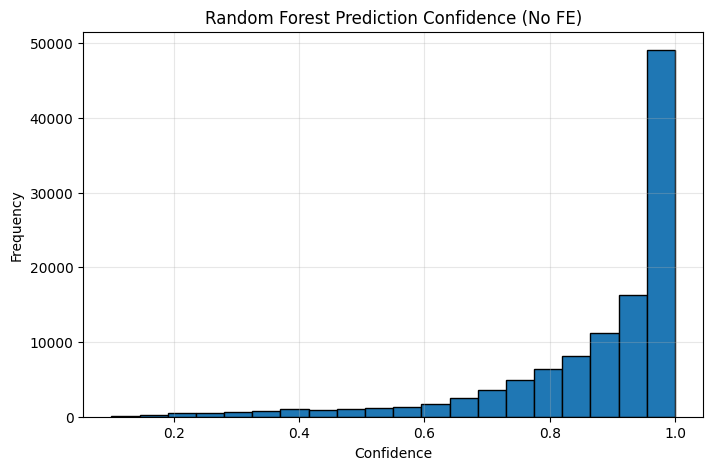

In [8]:
proba_rf = rf.predict_proba(X_test)
conf_rf = proba_rf.max(axis=1)

plt.figure(figsize=(8,5))
plt.hist(conf_rf, bins=20, edgecolor='black')
plt.title("Random Forest Prediction Confidence (No FE)")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler_rf = StandardScaler()
X_train_scaled_rf = scaler_rf.fit_transform(X_train)
X_test_scaled_rf = scaler_rf.transform(X_test)

pca_rf = PCA(n_components=100)
X_train_pca_rf = pca_rf.fit_transform(X_train_scaled_rf)
X_test_pca_rf = pca_rf.transform(X_test_scaled_rf)

rf_fe = RandomForestClassifier(n_estimators=200, random_state=42)
rf_fe.fit(X_train_pca_rf, y_train)

y_pred_rf_fe = rf_fe.predict(X_test_pca_rf)

acc_rf_fe = accuracy_score(y_test, y_pred_rf_fe)
print("Random Forest Accuracy With FE:", acc_rf_fe)

cm_rf_fe = confusion_matrix(y_test, y_pred_rf_fe)

plt.figure(figsize=(18,14))
sns.heatmap(cm_rf_fe, annot=False, cmap="viridis")
plt.title("Random Forest Confusion Matrix (With FE)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
